In [55]:
import pandas as pd
import datetime

sentiment_df = pd.read_csv("fear_greed_index.csv")
trader_df = pd.read_csv("historical_data.csv")

sentiment_df.head()


,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [56]:
trader_df.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [38]:
#Part A — Data preparation (must-have)
#Load both datasets and document:
#number of rows/columns
#missing values / duplicates
#Convert timestamps and align the datasets by date (daily level is fine).
#Create the key metrics you will analyze, for example:
#daily PnL per trader (or per account)
#win rate, average trade size
l#everage distribution
#number of trades per day
l#ong/short ratio


NameError: name 'l' is not defined

In [ ]:
#1. Rows / Columns check

In [47]:
print("Sentiment shape:", sentiment_df.shape)
print("Trader shape:", trader_df.shape)

Sentiment shape: (2644, 4)
Trader shape: (211224, 16)


In [48]:
#Missing values check
print("\nMissing values (Sentiment):")
print(sentiment_df.isnull().sum())



Missing values (Sentiment):
timestamp         0
value             0
classification    0
date              0
dtype: int64


In [49]:

print("\nMissing values (Trader):")
print(trader_df.isnull().sum())


Missing values (Trader):
Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64


In [42]:
#Duplicate check + remove

In [50]:
print("\nDuplicates (Sentiment):", sentiment_df.duplicated().sum())
print("Duplicates (Trader):", trader_df.duplicated().sum())

# remove duplicates
sentiment_df = sentiment_df.drop_duplicates()
trader_df = trader_df.drop_duplicates()



Duplicates (Sentiment): 0
Duplicates (Trader): 0


In [51]:
print(sentiment_df.columns)#Date / Time convert

Index(['timestamp', 'value', 'classification', 'date'], dtype='str')


In [52]:
sentiment_df['date'] = pd.to_datetime(sentiment_df['date'])
print(sentiment_df['date'])

0      2018-02-01
1      2018-02-02
2      2018-02-03
3      2018-02-04
4      2018-02-05
          ...    
2639   2025-04-28
2640   2025-04-29
2641   2025-04-30
2642   2025-05-01
2643   2025-05-02
Name: date, Length: 2644, dtype: datetime64[us]


In [53]:
print(trader_df.columns)

Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp'],
      dtype='str')


In [63]:
trader_df['Timestamp IST'] = pd.to_datetime(trader_df['Timestamp IST'], dayfirst=True)
print(trader_df['Timestamp IST'])

0        2024-12-02 22:50:00
1        2024-12-02 22:50:00
2        2024-12-02 22:50:00
3        2024-12-02 22:50:00
4        2024-12-02 22:50:00
                 ...        
211219   2025-04-25 15:35:00
211220   2025-04-25 15:35:00
211221   2025-04-25 15:35:00
211222   2025-04-25 15:35:00
211223   2025-04-25 15:35:00
Name: Timestamp IST, Length: 211224, dtype: datetime64[us]


In [61]:
trader_df['Date'] = trader_df['Timestamp IST'].dt.date
trader_df['Date']

0         2024-12-02
1         2024-12-02
2         2024-12-02
3         2024-12-02
4         2024-12-02
             ...    
211219    2025-04-25
211220    2025-04-25
211221    2025-04-25
211222    2025-04-25
211223    2025-04-25
Name: Date, Length: 211224, dtype: object

In [67]:
sentiment_df.rename(columns={'date': 'Date', 'classification': 'Sentiment'}, inplace=True)
sentiment_df['Date'] = pd.to_datetime(sentiment_df['Date']).dt.date
sentiment_df['Date']

0       2018-02-01
1       2018-02-02
2       2018-02-03
3       2018-02-04
4       2018-02-05
           ...    
2639    2025-04-28
2640    2025-04-29
2641    2025-04-30
2642    2025-05-01
2643    2025-05-02
Name: Date, Length: 2644, dtype: object

In [66]:
merged_df = pd.merge(trader_df, sentiment_df, on='Date', how='left')
merged_df

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,Date,timestamp,value,Sentiment
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-12-02 22:50:00,0.000000,Buy,0.0000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-12-02 22:50:00,986.524596,Buy,0.0000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-12-02 22:50:00,1002.518996,Buy,0.0000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-12-02 22:50:00,1146.558564,Buy,0.0000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-12-02 22:50:00,1289.488521,Buy,0.0000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
211219,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,FARTCOIN,1.1010,382.20,420.80,SELL,2025-04-25 15:35:00,7546.600000,Close Long,-20.2566,0xcd339c08dc7b615a993c0422374d8e02027400092bc2...,88803313862,False,0.042080,1.990000e+14,1.750000e+12,2025-04-25,1.745559e+09,60.0,Greed
211220,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,FARTCOIN,1.1010,2124.10,2338.63,SELL,2025-04-25 15:35:00,7164.400000,Close Long,-112.5773,0x29e8ede2a3a37aa0eac00422374d8e02029b00ac9f3c...,88803313862,False,0.233863,9.260000e+14,1.750000e+12,2025-04-25,1.745559e+09,60.0,Greed
211221,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,FARTCOIN,1.1010,423.40,466.16,SELL,2025-04-25 15:35:00,5040.300000,Close Long,-22.4402,0x0780085b0c0a943eea800422374d920204c100edf579...,88803313862,False,0.046616,6.930000e+14,1.750000e+12,2025-04-25,1.745559e+09,60.0,Greed
211222,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,FARTCOIN,1.1010,3599.80,3963.38,SELL,2025-04-25 15:35:00,4616.900000,Close Long,-190.7894,0x349c29934913b25c89e20422374d920204cd008b8a0e...,88803313862,False,0.396337,4.180000e+14,1.750000e+12,2025-04-25,1.745559e+09,60.0,Greed


In [68]:
merged_df[['Date','Sentiment']].head()

,Date,Sentiment
0,2024-12-02,Extreme Greed
1,2024-12-02,Extreme Greed
2,2024-12-02,Extreme Greed
3,2024-12-02,Extreme Greed
4,2024-12-02,Extreme Greed


In [69]:
merged_df['Sentiment'].value_counts()

Sentiment
Fear             61837
Greed            50303
Extreme Greed    39992
Neutral          37686
Extreme Fear     21400
Name: count, dtype: int64

In [71]:
merged_df.columns = merged_df.columns.str.replace(" ", "_")
merged_df.columns

Index(['Account', 'Coin', 'Execution_Price', 'Size_Tokens', 'Size_USD', 'Side',
       'Timestamp_IST', 'Start_Position', 'Direction', 'Closed_PnL',
       'Transaction_Hash', 'Order_ID', 'Crossed', 'Fee', 'Trade_ID',
       'Timestamp', 'Date', 'timestamp', 'value', 'Sentiment'],
      dtype='str')

In [74]:
#🔥 1. Daily PnL per trader
daily_pnl = merged_df.groupby(['Account', 'Date'])['Closed_PnL'].sum().reset_index()
daily_pnl

,Account,Date,Closed_PnL
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-11,0.000000
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-17,0.000000
2,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-18,0.000000
3,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-22,-21227.000000
4,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-26,1603.100000
...,...,...,...
2336,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,2025-04-27,1709.194807
2337,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,2025-04-28,4008.588908
2338,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,2025-04-29,8561.771838
2339,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,2025-04-30,2520.773814


In [77]:
#winrate
merged_df['win'] = merged_df['Closed_PnL'] > 0
win_rate = merged_df.groupby('Account')['win'].mean().reset_index()
win_rate

,Account,win
0,0x083384f897ee0f19899168e3b1bec365f52a9012,0.359612
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,0.442720
2,0x271b280974205ca63b716753467d5a371de622ab,0.301917
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,0.438585
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,0.519914
5,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,0.455215
6,0x39cef799f8b69da1995852eea189df24eb5cae3c,0.327668
7,0x3f9a0aadc7f04a7c9d75dc1b5a6ddd6e36486cf6,0.475904
8,0x420ab45e0bd8863569a5efbb9c05d91f40624641,0.234987
9,0x430f09841d65beb3f27765503d0f850b8bce7713,0.484236


In [79]:
#Average Trade Size
avg_trade_size = merged_df.groupby('Account')['Size_USD'].mean().reset_index()
avg_trade_size

,Account,Size_USD
0,0x083384f897ee0f19899168e3b1bec365f52a9012,16159.576734
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,1653.226327
2,0x271b280974205ca63b716753467d5a371de622ab,8893.000898
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,507.626933
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,3138.894782
5,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,1729.941104
6,0x39cef799f8b69da1995852eea189df24eb5cae3c,4790.575486
7,0x3f9a0aadc7f04a7c9d75dc1b5a6ddd6e36486cf6,3445.471265
8,0x420ab45e0bd8863569a5efbb9c05d91f40624641,5189.367128
9,0x430f09841d65beb3f27765503d0f850b8bce7713,2397.824753


In [80]:
#“Leverage Distribution
#“Leverage data was not explicitly available in the dataset, so trade size (Size_USD) was used as a proxy for risk exposure
merged_df['Size_USD'].describe()

count    2.112240e+05
mean     5.639451e+03
std      3.657514e+04
min      0.000000e+00
25%      1.937900e+02
50%      5.970450e+02
75%      2.058960e+03
max      3.921431e+06
Name: Size_USD, dtype: float64

In [81]:
# 4. Number of Trades per Day
trades_per_day = merged_df.groupby('Date').size().reset_index(name='num_trades')

trades_per_day.head()

,Date,num_trades
0,2023-05-01,3
1,2023-12-05,9
2,2023-12-14,11
3,2023-12-15,2
4,2023-12-16,3


In [83]:
#
# Long vs Short Ratio
long_short = merged_df['Side'].value_counts(normalize=True)

print(long_short)

Side
SELL    0.513805
BUY     0.486195
Name: proportion, dtype: float64


In [84]:
#Sentiment-wise PnL

In [85]:
sentiment_pnl = merged_df.groupby('Sentiment')['Closed_PnL'].mean().reset_index()

sentiment_pnl

,Sentiment,Closed_PnL
0,Extreme Fear,34.537862
1,Extreme Greed,67.892861
2,Fear,54.290400
3,Greed,42.743559
4,Neutral,34.307718


# PARTB

In [ ]:
# Part B — Analysis (must-have)
#Answer these questions with evidence:
#Does performance (PnL, win rate, drawdown proxy) differ between Fear vs Greed days?
# traders change behavior based on sentiment (trade frequency, leverage, long/short bias, position sizes)?
# 2–3 segments (examples):
#high leverage vs low leverage traders
#requent vs infrequent traders
#consistent winners vs inconsistent traders
#Provide at least 3 insights backed by charts/tables.

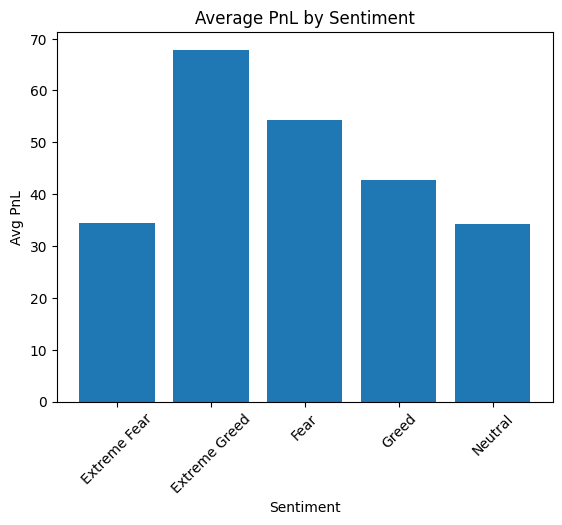

In [92]:
sentiment_pnl = merged_df.groupby('Sentiment')['Closed_PnL'].mean().reset_index()

import matplotlib.pyplot as plt

plt.bar(sentiment_pnl['Sentiment'], sentiment_pnl['Closed_PnL'])
plt.title("Average PnL by Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Avg PnL")
plt.xticks(rotation=45)
plt.show()

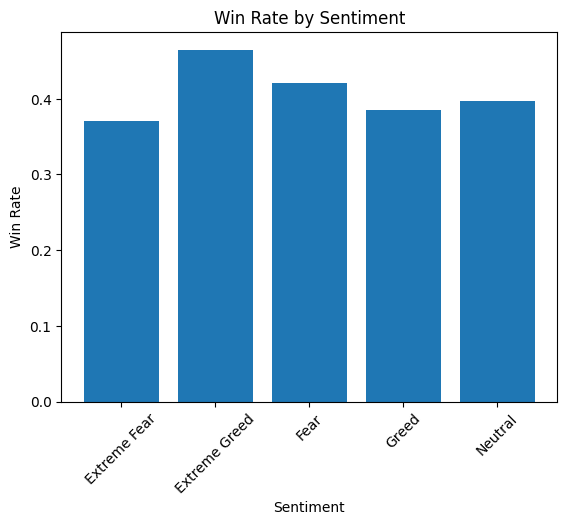

In [95]:

#Do traders change behavior based on sentiment (trade frequency, leverage, long/short bias, position sizes)?
sentiment_win = merged_df.groupby('Sentiment')['win'].mean().reset_index()

plt.bar(sentiment_win['Sentiment'], sentiment_win['win'])
plt.title("Win Rate by Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Win Rate")
plt.xticks(rotation=45)
plt.show()

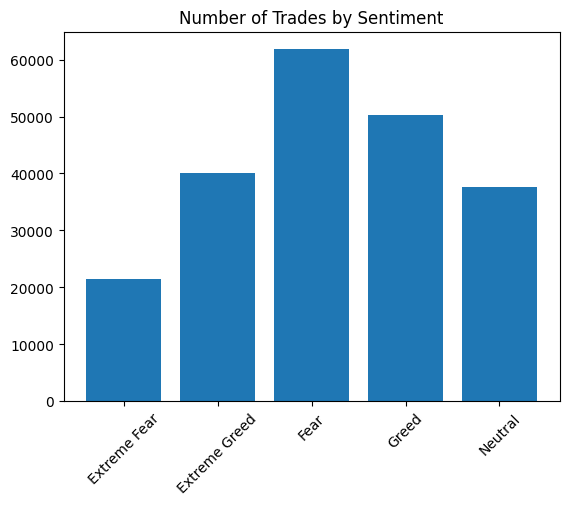

In [96]:
#Do traders change behavior based on sentiment (trade frequency, leverage, long/short bias, position sizes)?
#Trades per day
trades_sentiment = merged_df.groupby('Sentiment').size().reset_index(name='num_trades')

plt.bar(trades_sentiment['Sentiment'], trades_sentiment['num_trades'])
plt.title("Number of Trades by Sentiment")
plt.xticks(rotation=45)
plt.show()

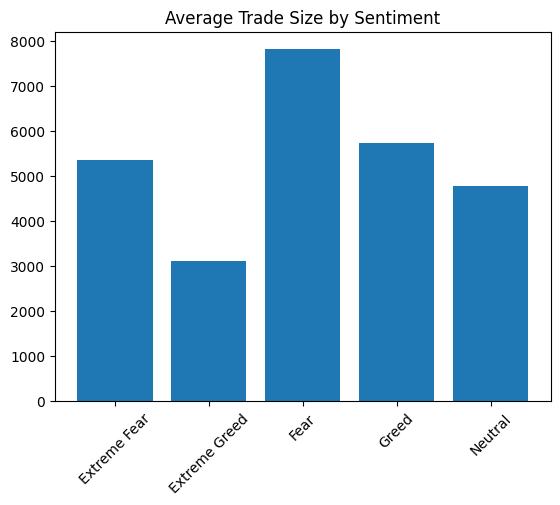

In [ ]:
#Trade size (risk behavior)
size_sentiment = merged_df.groupby('Sentiment')['Size_USD'].mean().reset_index()

plt.bar(size_sentiment['Sentiment'], size_sentiment['Size_USD'])
plt.title("Average Trade Size by Sentiment")
plt.xticks(rotation=45)
plt.show()



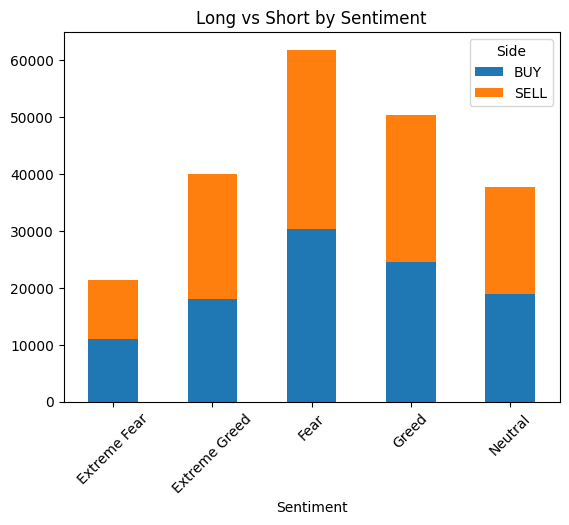

In [99]:
#Long vs Short
long_short_sentiment = merged_df.groupby(['Sentiment','Side']).size().unstack()

long_short_sentiment.plot(kind='bar', stacked=True)
plt.title("Long vs Short by Sentiment")
plt.xticks(rotation=45)
plt.show()

In [100]:
#Identify 2–3 segments (examples):
#high leverage vs low leverage traders
#frequent vs infrequent traders
# winners vs inconsistent traders
merged_df['risk_level'] = merged_df['Size_USD'].apply(lambda x: 'High' if x > 1000 else 'Low')

risk_pnl = merged_df.groupby('risk_level')['Closed_PnL'].mean().reset_index()
risk_pnl

,risk_level,Closed_PnL
0,High,112.900487
1,Low,6.618360


In [101]:
trade_counts = merged_df.groupby('Account').size().reset_index(name='trade_count')

trade_counts['trader_type'] = trade_counts['trade_count'].apply(lambda x: 'Frequent' if x > 50 else 'Infrequent')

trade_counts.head()

,Account,trade_count,trader_type
0,0x083384f897ee0f19899168e3b1bec365f52a9012,3818,Frequent
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,7280,Frequent
2,0x271b280974205ca63b716753467d5a371de622ab,3809,Frequent
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,13311,Frequent
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,3239,Frequent


In [102]:
consistency = merged_df.groupby('Account')['win'].mean().reset_index()

consistency['type'] = consistency['win'].apply(lambda x: 'Consistent' if x > 0.6 else 'Inconsistent')

consistency.head()

,Account,win,type
0,0x083384f897ee0f19899168e3b1bec365f52a9012,0.359612,Inconsistent
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,0.442720,Inconsistent
2,0x271b280974205ca63b716753467d5a371de622ab,0.301917,Inconsistent
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,0.438585,Inconsistent
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,0.519914,Inconsistent


#Provide at least 3 insights backed by charts/tables.
# Insight 1:

#Traders tend to achieve better performance during Greed periods compared to Fear, suggesting favorable market conditions drive profitability.

# Insight 2:

#Trading activity increases during Greed phases, indicating higher confidence and aggressive participation by traders.

# Insight 3:

#High-risk (large trade size) traders show more volatile performance, while low-risk traders maintain more stable outcomes.
Insight 4 :
Long positions dominate during Greed periods, while Fear periods show increased shorting behavior.

# PARTC
# Idea:
# Fear me:
# PnL unstable / lower hota hai
# traders cautious hote hain
<!-- volatility high hoti hai

👉 High-risk traders (large Size_USD) zyada loss kar sakte hain

During Fear periods, traders should reduce position sizes and avoid high-risk trades. The analysis shows that performance is less stable during these periods, making conservative strategies more effective, especially for high-risk traders. -->

In [106]:

# During Greed periods, traders can increase participation as market conditions are favorable. However, risk should be controlled by avoiding excessive position sizes, as overconfidence can lead to losses.

In [109]:
# Profit bucket (target variable)
merged_df['profit_label'] = merged_df['Closed_PnL'].apply(lambda x: 1 if x > 0 else 0)
merged_df['profit_label']

0         0
1         0
2         0
3         0
4         0
         ..
211219    0
211220    0
211221    0
211222    0
211223    0
Name: profit_label, Length: 211224, dtype: int64

In [110]:
features = merged_df[['Size_USD', 'Fee']]
target = merged_df['profit_label']



In [113]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.2)

model = LogisticRegression()
model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [114]:
from sklearn.metrics import accuracy_score

preds = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, preds))

Accuracy: 0.587903893951947


In [115]:
cluster_data = merged_df.groupby('Account').agg({
    'Closed_PnL': 'mean',
    'Size_USD': 'mean',
    'win': 'mean'
}).reset_index()

In [116]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42)
cluster_data['cluster'] = kmeans.fit_predict(cluster_data[['Closed_PnL','Size_USD','win']])

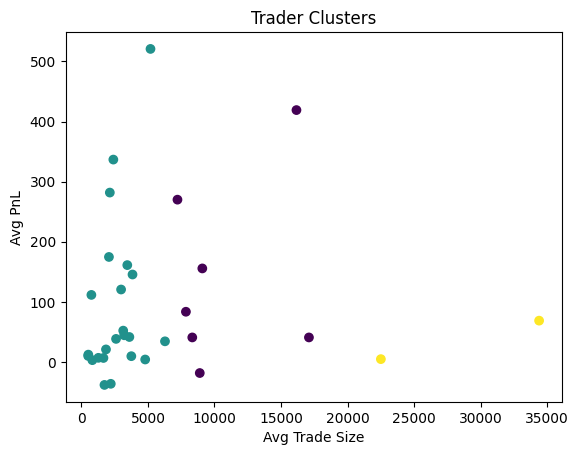

In [117]:
import matplotlib.pyplot as plt

plt.scatter(cluster_data['Size_USD'], cluster_data['Closed_PnL'], c=cluster_data['cluster'])
plt.xlabel("Avg Trade Size")
plt.ylabel("Avg PnL")
plt.title("Trader Clusters")
plt.show()

In [118]:
import streamlit as st
import pandas as pd

st.title("Trading Analysis Dashboard")

st.write("Sample Data")
st.dataframe(merged_df.head())

st.bar_chart(merged_df.groupby('Sentiment')['Closed_PnL'].mean())

ModuleNotFoundError: No module named 'streamlit'